# Image classification

## Load Food-101 dataset

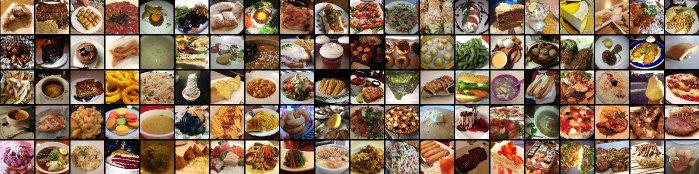

In [1]:
# !pip install datasets
# !pip install playsound
# !pip install sounddevice
# !pip install pydub
# !pip install pyaudio
# !pip install librosa
# !pip install numpy==1.23.5
# !pip install -U accelerate
# !pip install evaluate

import warnings
warnings.filterwarnings('ignore')


In [8]:
from datasets import load_dataset

# food = load_dataset("food101", split="train[:5000]")
food = load_dataset("rajistics/indian_food_images")


Generating train split:   0%|          | 0/5328 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/941 [00:00<?, ? examples/s]

In [3]:
# food = food.train_test_split(test_size=0.2)


In [9]:
# count classes in the dataset

food


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5328
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 941
    })
})

In [10]:
food["train"][0]


{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=480x360>,
 'label': 6}

Each example in the dataset has two fields:

- `image`: a PIL image of the food item
- `label`: the label class of the food item

To make it easier for the model to get the label name from the label id, create a dictionary that maps the label name
to an integer and vice versa:

In [11]:
labels = food["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label


Now you can convert the label id to a label name:

In [12]:
print(label2id)
print(id2label)


{'burger': '0', 'butter_naan': '1', 'chai': '2', 'chapati': '3', 'chole_bhature': '4', 'dal_makhani': '5', 'dhokla': '6', 'fried_rice': '7', 'idli': '8', 'jalebi': '9', 'kaathi_rolls': '10', 'kadai_paneer': '11', 'kulfi': '12', 'masala_dosa': '13', 'momos': '14', 'paani_puri': '15', 'pakode': '16', 'pav_bhaji': '17', 'pizza': '18', 'samosa': '19'}
{'0': 'burger', '1': 'butter_naan', '2': 'chai', '3': 'chapati', '4': 'chole_bhature', '5': 'dal_makhani', '6': 'dhokla', '7': 'fried_rice', '8': 'idli', '9': 'jalebi', '10': 'kaathi_rolls', '11': 'kadai_paneer', '12': 'kulfi', '13': 'masala_dosa', '14': 'momos', '15': 'paani_puri', '16': 'pakode', '17': 'pav_bhaji', '18': 'pizza', '19': 'samosa'}


## Preprocess

The next step is to load a ViT image processor to process the image into a tensor:

In [13]:
from transformers import AutoImageProcessor

checkpoint = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)


Apply some image transformations to the images to make the model more robust against overfitting. Here you'll use torchvision's [`transforms`](https://pytorch.org/vision/stable/transforms.html) module, but you can also use any image library you like.

Crop a random part of the image, resize it, and normalize it with the image mean and standard deviation:

In [14]:
from torchvision.transforms import RandomResizedCrop, Compose, Normalize, ToTensor

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
size = (
    image_processor.size["shortest_edge"]
    if "shortest_edge" in image_processor.size
    else (image_processor.size["height"], image_processor.size["width"])
)
_transforms = Compose([RandomResizedCrop(size), ToTensor(), normalize])


Then create a preprocessing function to apply the transforms and return the `pixel_values` - the inputs to the model - of the image:

In [15]:
def transforms(examples):
    examples["pixel_values"] = [_transforms(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples


To apply the preprocessing function over the entire dataset, use 🤗 Datasets [with_transform](https://huggingface.co/docs/datasets/main/en/package_reference/main_classes#datasets.Dataset.with_transform) method. The transforms are applied on the fly when you load an element of the dataset:

In [16]:
food = food.with_transform(transforms)


Now create a batch of examples using [DefaultDataCollator](https://huggingface.co/docs/transformers/main/en/main_classes/data_collator#transformers.DefaultDataCollator). Unlike other data collators in 🤗 Transformers, the `DefaultDataCollator` does not apply additional preprocessing such as padding.

In [17]:
from transformers import DefaultDataCollator

data_collator = DefaultDataCollator()


## Evaluate

Including a metric during training is often helpful for evaluating your model's performance. You can quickly load an
evaluation method with the 🤗 [Evaluate](https://huggingface.co/docs/evaluate/index) library. For this task, load
the [accuracy](https://huggingface.co/spaces/evaluate-metric/accuracy) metric (see the 🤗 Evaluate [quick tour](https://huggingface.co/docs/evaluate/a_quick_tour) to learn more about how to load and compute a metric):

In [18]:
import evaluate

accuracy = evaluate.load("accuracy")


Then create a function that passes your predictions and labels to [compute](https://huggingface.co/docs/evaluate/main/en/package_reference/main_classes#evaluate.EvaluationModule.compute) to calculate the accuracy:

In [19]:
import numpy as np


def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)


Your `compute_metrics` function is ready to go now, and you'll return to it when you set up your training.

## Train

<Tip>

If you aren't familiar with finetuning a model with the [Trainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer), take a look at the basic tutorial [here](https://huggingface.co/docs/transformers/main/en/tasks/../training#train-with-pytorch-trainer)!

</Tip>

You're ready to start training your model now! Load ViT with [AutoModelForImageClassification](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForImageClassification). Specify the number of labels along with the number of expected labels, and the label mappings:

In [20]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
)


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


At this point, only three steps remain:

1. Define your training hyperparameters in [TrainingArguments](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments). It is important you don't remove unused columns because that'll drop the `image` column. Without the `image` column, you can't create `pixel_values`. Set `remove_unused_columns=False` to prevent this behavior! The only other required parameter is `output_dir` which specifies where to save your model. You'll push this model to the Hub by setting `push_to_hub=True` (you need to be signed in to Hugging Face to upload your model). At the end of each epoch, the [Trainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) will evaluate the accuracy and save the training checkpoint.
2. Pass the training arguments to [Trainer](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) along with the model, dataset, tokenizer, data collator, and `compute_metrics` function.
3. Call [train()](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

In [21]:
training_args = TrainingArguments(
    output_dir="my_awesome_food_model",
    remove_unused_columns=False,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=food["train"],
    eval_dataset=food["test"],
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
)

trainer.train()


  0%|          | 0/249 [00:00<?, ?it/s]

{'loss': 2.9825, 'grad_norm': 0.9980524778366089, 'learning_rate': 2e-05, 'epoch': 0.12}
{'loss': 2.9101, 'grad_norm': 1.0060460567474365, 'learning_rate': 4e-05, 'epoch': 0.24}
{'loss': 2.7613, 'grad_norm': 1.20248544216156, 'learning_rate': 4.888392857142857e-05, 'epoch': 0.36}
{'loss': 2.566, 'grad_norm': 1.217608094215393, 'learning_rate': 4.665178571428572e-05, 'epoch': 0.48}
{'loss': 2.3661, 'grad_norm': 1.2702451944351196, 'learning_rate': 4.4419642857142854e-05, 'epoch': 0.6}
{'loss': 2.1956, 'grad_norm': 1.2445740699768066, 'learning_rate': 4.21875e-05, 'epoch': 0.72}
{'loss': 1.9822, 'grad_norm': 1.2596465349197388, 'learning_rate': 3.9955357142857144e-05, 'epoch': 0.84}
{'loss': 1.8375, 'grad_norm': 1.4226603507995605, 'learning_rate': 3.7723214285714286e-05, 'epoch': 0.96}


  0%|          | 0/59 [00:00<?, ?it/s]

{'eval_loss': 1.7590528726577759, 'eval_accuracy': 0.8289054197662061, 'eval_runtime': 22.2384, 'eval_samples_per_second': 42.314, 'eval_steps_per_second': 2.653, 'epoch': 1.0}
{'loss': 1.6807, 'grad_norm': 1.3381398916244507, 'learning_rate': 3.5491071428571435e-05, 'epoch': 1.08}
{'loss': 1.5937, 'grad_norm': 1.3190321922302246, 'learning_rate': 3.325892857142857e-05, 'epoch': 1.2}
{'loss': 1.4977, 'grad_norm': 1.6971452236175537, 'learning_rate': 3.102678571428572e-05, 'epoch': 1.32}
{'loss': 1.4397, 'grad_norm': 1.45406973361969, 'learning_rate': 2.8794642857142857e-05, 'epoch': 1.44}
{'loss': 1.3392, 'grad_norm': 1.3409724235534668, 'learning_rate': 2.6562500000000002e-05, 'epoch': 1.56}
{'loss': 1.3049, 'grad_norm': 1.5289942026138306, 'learning_rate': 2.4330357142857144e-05, 'epoch': 1.68}
{'loss': 1.2613, 'grad_norm': 1.3462677001953125, 'learning_rate': 2.2098214285714286e-05, 'epoch': 1.8}
{'loss': 1.2015, 'grad_norm': 1.528958797454834, 'learning_rate': 1.9866071428571427e-0

  0%|          | 0/59 [00:00<?, ?it/s]

{'eval_loss': 1.2041139602661133, 'eval_accuracy': 0.873538788522848, 'eval_runtime': 22.0341, 'eval_samples_per_second': 42.706, 'eval_steps_per_second': 2.678, 'epoch': 1.99}
{'loss': 1.1311, 'grad_norm': 1.294456958770752, 'learning_rate': 1.7633928571428573e-05, 'epoch': 2.04}
{'loss': 1.1539, 'grad_norm': 1.2904701232910156, 'learning_rate': 1.5401785714285715e-05, 'epoch': 2.16}
{'loss': 1.0676, 'grad_norm': 1.4625911712646484, 'learning_rate': 1.3169642857142858e-05, 'epoch': 2.28}
{'loss': 1.102, 'grad_norm': 1.4870067834854126, 'learning_rate': 1.09375e-05, 'epoch': 2.4}
{'loss': 1.0568, 'grad_norm': 1.6433905363082886, 'learning_rate': 8.705357142857143e-06, 'epoch': 2.52}
{'loss': 1.0762, 'grad_norm': 1.5348151922225952, 'learning_rate': 6.473214285714287e-06, 'epoch': 2.64}
{'loss': 1.0458, 'grad_norm': 1.625548005104065, 'learning_rate': 4.241071428571429e-06, 'epoch': 2.76}
{'loss': 1.0371, 'grad_norm': 1.2408751249313354, 'learning_rate': 2.0089285714285715e-06, 'epoch':

  0%|          | 0/59 [00:00<?, ?it/s]

{'eval_loss': 1.074013113975525, 'eval_accuracy': 0.8724760892667375, 'eval_runtime': 22.0338, 'eval_samples_per_second': 42.707, 'eval_steps_per_second': 2.678, 'epoch': 2.99}
{'train_runtime': 665.6846, 'train_samples_per_second': 24.011, 'train_steps_per_second': 0.374, 'train_loss': 1.6255813047110317, 'epoch': 2.99}


TrainOutput(global_step=249, training_loss=1.6255813047110317, metrics={'train_runtime': 665.6846, 'train_samples_per_second': 24.011, 'train_steps_per_second': 0.374, 'total_flos': 1.235111572815741e+18, 'train_loss': 1.6255813047110317, 'epoch': 2.990990990990991})

## Inference

Great, now that you've fine-tuned a model, you can use it for inference!

Load an image you'd like to run inference on:

In [22]:
trainer.save_model("image_classification")


In [23]:
ds = load_dataset("food101", split="validation[:10]")
image = ds["image"][0]


<div class="flex justify-center">
    <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/beignets-task-guide.png" alt="image of beignets"/>
</div>

The simplest way to try out your finetuned model for inference is to use it in a [pipeline()](https://huggingface.co/docs/transformers/main/en/main_classes/pipelines#transformers.pipeline). Instantiate a `pipeline` for image classification with your model, and pass your image to it:

In [24]:
from transformers import pipeline

classifier = pipeline("image-classification", model="image_classification")
classifier(image)


[{'label': 'chai', 'score': 0.34416455030441284},
 {'label': 'kulfi', 'score': 0.05515892803668976},
 {'label': 'idli', 'score': 0.05055978521704674},
 {'label': 'dal_makhani', 'score': 0.050222549587488174},
 {'label': 'chapati', 'score': 0.039572060108184814}]

Get the predicted label with the highest probability, and use the model's `id2label` mapping to convert it to a label: